# Importing Libraries and Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("employee_salary_regression.csv")

# Data Inspection

In [3]:
df.head()

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60
2,EMP0003,36,13,Master,Data Analyst,1,4.1,7,1,142019.59
3,EMP0004,43,23,High School,DevOps,1,3.1,7,1,159972.80
4,EMP0005,24,1,High School,DevOps,1,3.7,12,1,94126.86


In [4]:
df.tail()

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
995,EMP0996,37,13,Master,ML Engineer,2,3.4,11,0,127579.68
996,EMP0997,27,5,PhD,Product Manager,3,4.5,6,1,96672.53
997,EMP0998,33,10,Bachelor,Software Engineer,3,4.2,9,1,107247.32
998,EMP0999,33,9,High School,DevOps,3,4.8,5,0,100412.67
999,EMP1000,40,20,Bachelor,DevOps,2,5.0,10,0,156563.24


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        1000 non-null   str    
 1   age                1000 non-null   int64  
 2   years_experience   1000 non-null   int64  
 3   education_level    1000 non-null   str    
 4   job_role           1000 non-null   str    
 5   city_tier          1000 non-null   int64  
 6   performance_score  1000 non-null   float64
 7   num_skills         1000 non-null   int64  
 8   remote_work        1000 non-null   int64  
 9   annual_salary_usd  1000 non-null   float64
dtypes: float64(2), int64(5), str(3)
memory usage: 103.4 KB


In [6]:
df.describe()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.668000,18.617000,2.046000,3.506200,7.161000,0.488000,137295.111970
std,11.536415,11.634848,0.826176,0.863775,3.103661,0.500106,34692.969621
min,22.000000,0.000000,1.000000,2.000000,2.000000,0.000000,66716.640000
25%,30.000000,8.000000,1.000000,2.800000,4.000000,0.000000,107616.092500
50%,41.000000,19.000000,2.000000,3.500000,7.000000,0.000000,137537.955000
75%,51.000000,29.000000,3.000000,4.300000,10.000000,1.000000,164807.105000
max,60.000000,40.000000,3.000000,5.000000,12.000000,1.000000,217067.540000


In [7]:
df.isnull().sum()

employee_id          0
age                  0
years_experience     0
education_level      0
job_role             0
city_tier            0
performance_score    0
num_skills           0
remote_work          0
annual_salary_usd    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

# Data Visualization

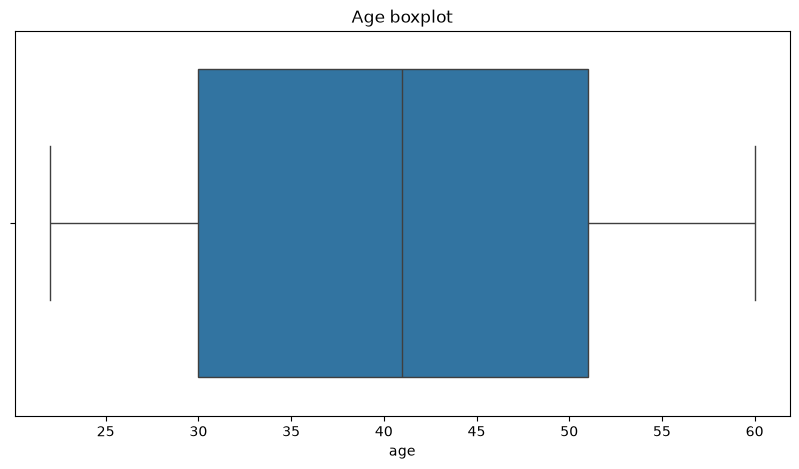

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="age")
plt.title("Age boxplot")
plt.show()

C:\Users\grana\AppData\Local\Temp\ipykernel_16560\1941078189.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="job_role", y="years_experience", palette="Set2")


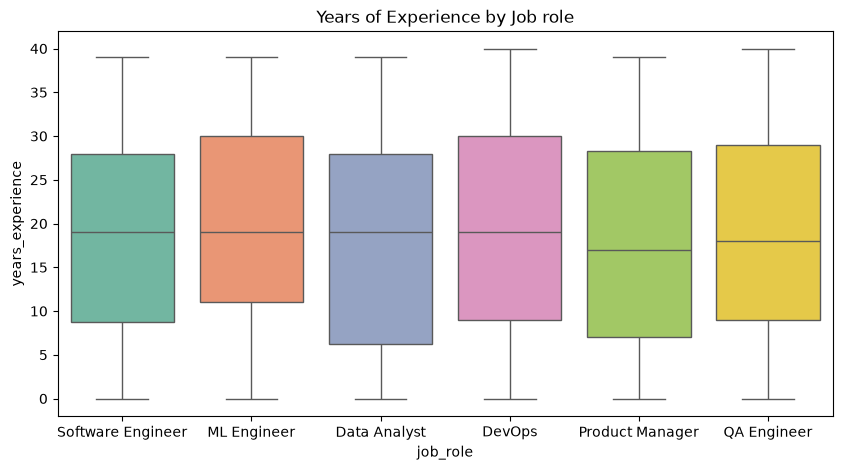

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="job_role", y="years_experience", palette="Set2")
plt.title("Years of Experience by Job role")
plt.show()

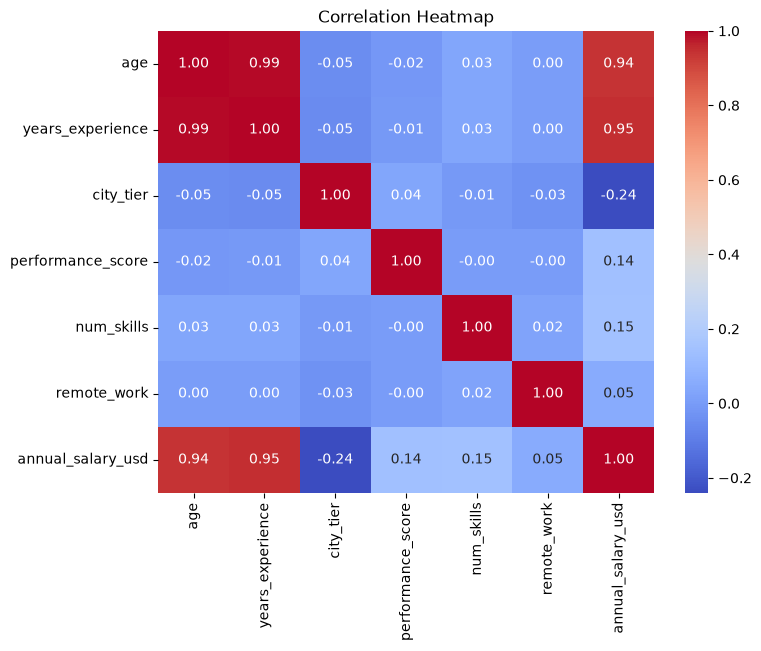

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

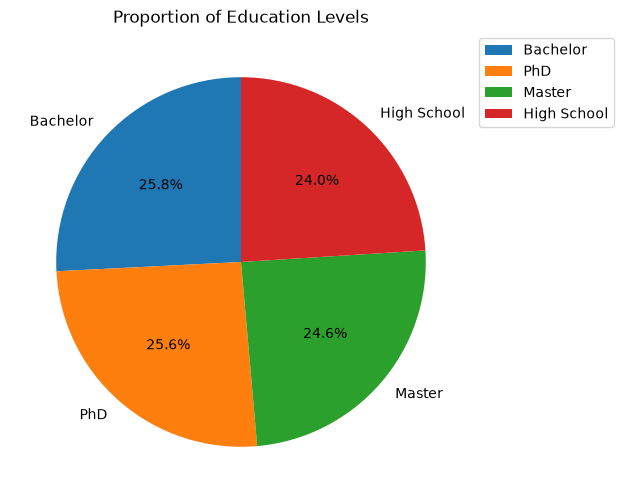

In [12]:
plt.figure(figsize=(6, 6))
counts_series = df["education_level"].value_counts()

# Plot the pie chart
counts_series.plot(
    kind="pie", 
    autopct="%1.1f%%", 
    startangle=90
)

plt.title("Proportion of Education Levels")
plt.ylabel("")

# Simply use the existing index strings for the legend
plt.legend(
    counts_series.index, 
    loc="best", 
    bbox_to_anchor=(1, 1)
)

plt.show()

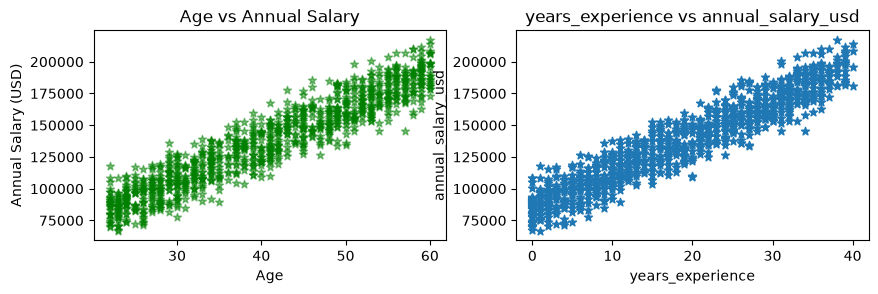

In [13]:
#Two scatter plots as subplots
x_plot = df['age']
y_plot = df['annual_salary_usd']

plt.figure(figsize=(10,6))
# Subplot - 1
plt.subplot(2,2,1)
plt.title('Age vs Annual Salary')
plt.xlabel('Age')
plt.ylabel('Annual Salary (USD)')
plt.scatter(x_plot,y_plot,marker='*',color = 'green',alpha = 0.5)
plt.subplot(2,2,2)
#Subplot - 2
plt.title("years_experience vs annual_salary_usd")
plt.xlabel("years_experience")
plt.ylabel("annual_salary_usd")
plt.scatter(df['years_experience'],df['annual_salary_usd'],marker='*')
plt.show()

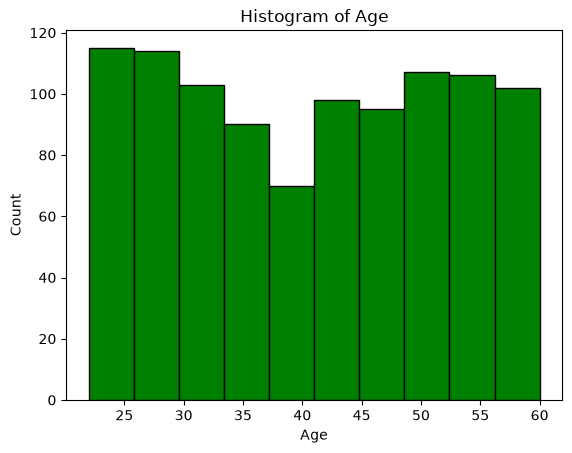

In [14]:
plt.hist(df['age'], bins = 10, edgecolor= 'black', color='green')
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Feature Engineering

In [15]:
encoder = LabelEncoder()
df['education_level'] = encoder.fit_transform(df['education_level'])
df['job_role'] = encoder.fit_transform(df['job_role'])

In [16]:
df['education_level'].unique()

array([2, 0, 1, 3])

In [17]:
df['job_role'].unique()

array([5, 2, 0, 1, 3, 4])

In [18]:
df['education_level']

0      2
1      0
2      2
3      1
4      1
      ..
995    2
996    3
997    0
998    1
999    0
Name: education_level, Length: 1000, dtype: int64

In [19]:
df['job_role']

0      5
1      2
2      0
3      1
4      1
      ..
995    2
996    3
997    5
998    1
999    1
Name: job_role, Length: 1000, dtype: int64

In [20]:
df.head()

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
0,EMP0001,29,9,2,5,1,2.4,3,0,106343.31
1,EMP0002,27,6,0,2,3,2.1,5,1,82852.60
2,EMP0003,36,13,2,0,1,4.1,7,1,142019.59
3,EMP0004,43,23,1,1,1,3.1,7,1,159972.80
4,EMP0005,24,1,1,1,1,3.7,12,1,94126.86


In [21]:
scaler = MinMaxScaler()
df['annual_salary_usd'] = scaler.fit_transform(
    df[['annual_salary_usd']])

In [22]:
df['annual_salary_usd'].min(), df['annual_salary_usd'].max()

(np.float64(0.0), np.float64(0.9999999999999999))

In [23]:
df.head()

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
0,EMP0001,29,9,2,5,1,2.4,3,0,0.263561
1,EMP0002,27,6,0,2,3,2.1,5,1,0.107322
2,EMP0003,36,13,2,0,1,4.1,7,1,0.500848
3,EMP0004,43,23,1,1,1,3.1,7,1,0.620257
4,EMP0005,24,1,1,1,1,3.7,12,1,0.182308


# M.L Model

In [24]:
X = df[['age', 'years_experience', 'education_level', 'city_tier', 'performance_score', 'num_skills', 'remote_work']]
y = df['annual_salary_usd']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
linear_reg_model = LinearRegression()
model_one = linear_reg_model.fit(X_train, y_train)
y_pred_one = model_one.predict(X_test)

In [27]:
decision_tree_model = DecisionTreeRegressor()
model_two = decision_tree_model.fit(X_train, y_train)
y_pred_two = model_two.predict(X_test)

In [28]:
random_forest_model = RandomForestRegressor()
model_three = random_forest_model.fit(X_train, y_train)
y_pred_three = model_three.predict(X_test)

In [29]:
# MAE : to know how much loss has occured.
mae_model_one = mean_absolute_error(y_test, y_pred_one)
mae_model_two = mean_absolute_error(y_test, y_pred_two)
mae_model_three = mean_absolute_error(y_test, y_pred_three)

print("MAE For Linear Reg: ", mae_model_one)
print("MAE For Decision Tree: ", mae_model_two)
print("MAE For Random Forest: ", mae_model_three)

MAE For Linear Reg:  0.027439038132061718
MAE For Decision Tree:  0.04637268682794716
MAE For Random Forest:  0.03164005166663452


In [30]:
mse_model_one = mean_squared_error(y_test,y_pred_one)
print("Mean Squared Error for Linear Regression:", mse_model_one)
mse_model_two = mean_squared_error(y_test,y_pred_two)
print("Mean Squared Error for Decision Tree:", mse_model_two)
mse_model_three = mean_squared_error(y_test,y_pred_three)
print("Mean Squared Error for Random Forest:", mse_model_three)

Mean Squared Error for Linear Regression: 0.0011616235230180146
Mean Squared Error for Decision Tree: 0.0031826607232708203
Mean Squared Error for Random Forest: 0.0015125198538796208


In [31]:
rms_model_one = np.sqrt(mean_squared_error(y_test,y_pred_one))
rms_model_two = np.sqrt(mean_squared_error(y_test,y_pred_two))
rms_model_three = np.sqrt(mean_squared_error(y_test,y_pred_three))
print("Root Mean Squared Error for Linear Regression:", rms_model_one)
print("Root Mean Squared Error for Decision Tree:", rms_model_two)
print("Root Mean Squared Error for Random Forest :", rms_model_three)

Root Mean Squared Error for Linear Regression: 0.03408259853676088
Root Mean Squared Error for Decision Tree: 0.05641507531919833
Root Mean Squared Error for Random Forest : 0.038891128215566347


In [32]:
# R2 Score - Used to know the accuracy. 
r2_score_1 = r2_score(y_test, y_pred_one)
r2_score_2 = r2_score(y_test, y_pred_two)
r2_score_3 = r2_score(y_test, y_pred_three)
print(f"R2 Score for Linear Reg: {r2_score_1}")
print(f"R2 Score for Decision tree: {r2_score_2}")
print(f"R2 Score for Random Forest: {r2_score_3}")

R2 Score for Linear Reg: 0.9800531026621191
R2 Score for Decision tree: 0.9453487249092111
R2 Score for Random Forest: 0.9740276624491396


In [33]:
test_data = [[20.0,	9, 2, 1, 0.0, 3, 2.4]]
result = model_one.predict(test_data)
print(result)

[0.21484156]


C:\Users\grana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [34]:
test_data = [[20.0,	9, 2, 1, 0.0, 3, 2.4]]
result = model_two.predict(test_data)
print(result)

[0.15848917]


C:\Users\grana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [35]:
test_data = [[20.0,	9, 2, 1, 0.0, 3, 2.4]]
result = model_three.predict(test_data)
print(result)

[0.24531814]


C:\Users\grana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
